In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from helper_function import plot_decision_boundary

/Users/kuroyami/neural_network_learning/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:

def accuracy_fn(y_true, y_pred):
    y_pred_class = torch.round(y_pred)  # convert probabilities to 0 or 1
    return (y_pred_class == y_true).float().mean() * 100


In [3]:
X, y = make_moons(n_samples = 10000, noise = 0.07, random_state = True)

In [4]:
X.shape, y.shape

((10000, 2), (10000,))

In [5]:
X[:5]

array([[ 2.01153753,  0.47241662],
       [-0.71831636,  0.7235773 ],
       [-1.01520454, -0.0244993 ],
       [-0.5968305 ,  0.64690623],
       [ 0.13221465,  0.28767715]])

In [6]:
y[:5]

array([1, 0, 0, 0, 1])

In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X.shape

(10000, 2)

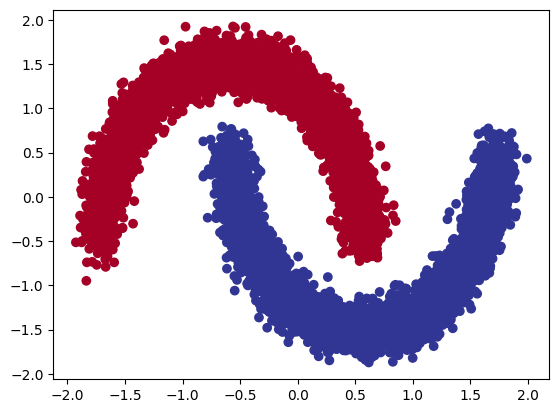

In [8]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [9]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [10]:
X, y = torch.from_numpy(X).type(torch.float).to(device), torch.from_numpy(y).type(torch.float).to(device)
X[:5]

tensor([[ 1.7376,  0.4456],
        [-1.4009,  0.9497],
        [-1.7422, -0.5517],
        [-1.2612,  0.7958],
        [-0.4230,  0.0749]], device='mps:0')

In [11]:
y.unique()

tensor([0., 1.], device='mps:0')

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
class MoonsClassification(nn.Module):
    def __init__(self, in_features: int = None, out_features: int = None, hidden_units: int = 8):
        super(MoonsClassification, self).__init__()
        self.in_features: int = in_features or X_train.shape[1]
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units 
        
        self.squencelayer = nn.Sequential(
            nn.Linear(in_features = self.in_features,
                     out_features = self.hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = self.hidden_units,
                     out_features = self.hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = self.hidden_units,
                     out_features = self.out_features),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.squencelayer(x)

In [14]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [15]:
model = MoonsClassification(out_features = 1, hidden_units = 8).to(device)
model

MoonsClassification(
  (squencelayer): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [16]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
y_pred[:10], y_test[:10]

(tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='mps:0'),
 tensor([1., 0., 1., 1., 0., 0., 1., 1., 0., 1.], device='mps:0'))

In [17]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.1)

In [ ]:
epochs = 1000
total_epochs = []
losses = []
test_losses = []

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    train_accuracy = accuracy_fn(y_train, y_pred)
    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))
        test_accuracy = accuracy_fn(y_test, y_test_pred)
        test_loss = loss_fn(y_test_logits, y_test)
        test_losses.append(test_loss)

    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Train Loss: {loss} | Test Loss: {test_loss}")
        print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}\n")

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)